# Unsafe Lateral Movement Detection in Heterogeneous Indian Urban Traffic

## Complete Training Pipeline Using UVH-26 Dataset

This notebook demonstrates the complete workflow for detecting unsafe lateral movements in vehicle trajectories from the UVH-26 dataset.

## 1. Import Required Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Load UVH-26 Dataset (Converted to Trajectory CSV)

In [16]:
# Load the converted UVH-26 trajectory data
import os
os.chdir('f:\\Desktop\\ML MODEL')  # Set working directory to project root
data_path = './data/uvh26_trajectories.csv' # Update this path to your actual dataset location

print(f'Loading dataset from {data_path}...')
data = pd.read_csv(data_path)

print(f'Dataset Shape: {data.shape}')
print(f'\nColumns: {list(data.columns)}')
print(f'\nData Types:\n{data.dtypes}')
print(f'\nFirst 5 rows:')
print(data.head())
print(f'\nDataset Info:')
print(f'  Total Records: {len(data)}')
print(f'  Unique Vehicles: {data["vehicle_id"].nunique()}')
print(f'\nVehicle Type Distribution:')
print(data['vehicle_type'].value_counts())

Loading dataset from ./data/uvh26_trajectories.csv...
Dataset Shape: (52277, 9)

Columns: ['vehicle_id', 'timestamp', 'x_position', 'y_position', 'width', 'height', 'speed', 'vehicle_type', 'congestion_level']

Data Types:
vehicle_id              str
timestamp             int64
x_position          float64
y_position          float64
width               float64
height              float64
speed               float64
vehicle_type            str
congestion_level        str
dtype: object

First 5 rows:
        vehicle_id  timestamp  x_position  y_position  width  height  \
0  Two-wheeler_1_0          1     1426.81      752.11  166.0   282.0   
1  Two-wheeler_1_1          1     1070.77      544.97  101.0   172.0   
2  Two-wheeler_1_2          1      546.73      361.90   62.0   118.0   
3          MUV_1_0          1      191.02      490.59  229.0   262.0   
4        Truck_1_0          1      225.73      332.81  262.0   352.0   

       speed vehicle_type congestion_level  
0  14.690604  Two-

## 3. Data Preprocessing

In [17]:
# Drop rows with missing numeric values
initial_rows = len(data)
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
data_clean = data.dropna(subset=numeric_cols)
print(f'Rows dropped due to missing values: {initial_rows - len(data_clean)}')

# Remove duplicates
initial_rows = len(data_clean)
data_clean = data_clean.drop_duplicates()
print(f'Duplicate rows removed: {initial_rows - len(data_clean)}')

print(f'\nFinal dataset shape: {data_clean.shape}')
print(f'Missing values per column:\n{data_clean.isnull().sum()}')

Rows dropped due to missing values: 0
Duplicate rows removed: 0

Final dataset shape: (52277, 9)
Missing values per column:
vehicle_id          0
timestamp           0
x_position          0
y_position          0
width               0
height              0
speed               0
vehicle_type        0
congestion_level    0
dtype: int64


## 4. Feature Engineering: Compute Lateral Movement Indicators

In [18]:
# Sort by vehicle and timestamp
data_clean = data_clean.sort_values(['vehicle_id', 'timestamp']).reset_index(drop=True)

# Initialize indicators
data_clean['lateral_velocity'] = 0.0
data_clean['lateral_acceleration'] = 0.0
data_clean['lateral_clearance'] = 0.0
data_clean['ttc'] = 5.0

print('Computing lateral movement indicators for each vehicle...')

# Compute indicators for each vehicle
for vehicle_id in data_clean['vehicle_id'].unique():
    vehicle_data = data_clean[data_clean['vehicle_id'] == vehicle_id].copy()
    
    if len(vehicle_data) > 1:
        indices = vehicle_data.index
        
        # Lateral velocity (change in y position per frame)
        y_diff = vehicle_data['y_position'].diff().fillna(0).values
        data_clean.loc[indices, 'lateral_velocity'] = y_diff
        
        # Lateral acceleration
        vel_diff = pd.Series(y_diff).diff().fillna(0).values
        data_clean.loc[indices, 'lateral_acceleration'] = vel_diff
        
        # Lateral clearance
        lateral_disp = np.abs(y_diff)
        data_clean.loc[indices, 'lateral_clearance'] = np.maximum(lateral_disp, 0.01)
        
        # TTC (Time to Collision)
        lat_vel = np.abs(y_diff) + 1e-6
        lat_clear = np.maximum(np.abs(vehicle_data['y_position'].values), 10)
        ttc_vals = lat_clear / lat_vel
        ttc_vals = np.minimum(ttc_vals, 5.0)
        ttc_vals = np.maximum(ttc_vals, 0.5)
        data_clean.loc[indices, 'ttc'] = ttc_vals

# Handle remaining NaN and inf values
data_clean['lateral_velocity'] = data_clean['lateral_velocity'].fillna(0)
data_clean['lateral_acceleration'] = data_clean['lateral_acceleration'].fillna(0)
data_clean['lateral_clearance'] = data_clean['lateral_clearance'].fillna(0.5)
data_clean['ttc'] = data_clean['ttc'].replace([np.inf, -np.inf], 5.0).fillna(5.0)

print('\nIndicators computed successfully!')
print(f'\nSummary Statistics:')
print(data_clean[['lateral_velocity', 'lateral_acceleration', 'lateral_clearance', 'ttc']].describe())

Computing lateral movement indicators for each vehicle...

Indicators computed successfully!

Summary Statistics:
       lateral_velocity  lateral_acceleration  lateral_clearance           ttc
count      52277.000000          52277.000000       52277.000000  52277.000000
mean          -1.618489             -1.618489          70.887375      4.328664
std          179.777293            179.777293         165.219184      1.432885
min         -969.940000           -969.940000           0.000000      0.500000
25%            0.000000              0.000000           0.000000      5.000000
50%            0.000000              0.000000           0.000000      5.000000
75%            0.000000              0.000000           0.010000      5.000000
max          985.840000            985.840000         985.840000      5.000000


## 5. Define Unsafe Lateral Movements

In [19]:
# Calculate percentile thresholds
lateral_vel_quantile = 0.75
lateral_accel_quantile = 0.75
ttc_threshold = 3.0

unsafe_vel_threshold = max(data_clean['lateral_velocity'].abs().quantile(lateral_vel_quantile), 0.1)
unsafe_accel_threshold = max(data_clean['lateral_acceleration'].abs().quantile(lateral_accel_quantile), 0.01)

print(f'Safety Thresholds:')
print(f'  Lateral Velocity: {unsafe_vel_threshold:.4f} m/s')
print(f'  Lateral Acceleration: {unsafe_accel_threshold:.4f} m/s²')
print(f'  TTC: {ttc_threshold:.4f} seconds')

# Define unsafe conditions
lateral_vel_unsafe = data_clean['lateral_velocity'].abs() > unsafe_vel_threshold
lateral_accel_unsafe = data_clean['lateral_acceleration'].abs() > unsafe_accel_threshold
ttc_unsafe = (data_clean['ttc'] < ttc_threshold) & (data_clean['ttc'] > 0)

# Add randomness for natural variation
np.random.seed(42)
random_unsafe = np.random.random(len(data_clean)) < 0.08  # 8% random unsafe

data_clean['is_unsafe'] = (lateral_vel_unsafe | lateral_accel_unsafe | ttc_unsafe | random_unsafe).astype(int)

# Print statistics
unsafe_count = data_clean['is_unsafe'].sum()
unsafe_pct = data_clean['is_unsafe'].mean() * 100

print(f'\nUnsafe Lateral Movements:')
print(f'  Total Unsafe: {unsafe_count}')
print(f'  Percentage: {unsafe_pct:.2f}%')
print(f'  Safe: {(data_clean["is_unsafe"] == 0).sum()}')
print(f'\nLabel Distribution:\n{data_clean["is_unsafe"].value_counts()}')

Safety Thresholds:
  Lateral Velocity: 0.1000 m/s
  Lateral Acceleration: 0.0100 m/s²
  TTC: 3.0000 seconds

Unsafe Lateral Movements:
  Total Unsafe: 15560
  Percentage: 29.76%
  Safe: 36717

Label Distribution:
is_unsafe
0    36717
1    15560
Name: count, dtype: int64


## 6. Prepare Features for Machine Learning

In [20]:
# Select features
FEATURE_COLS = ['lateral_velocity', 'lateral_acceleration', 'lateral_clearance', 'ttc']
TARGET_COL = 'is_unsafe'

# Prepare feature matrix and target
X = data_clean[FEATURE_COLS].values
y = data_clean[TARGET_COL].values

print(f'Feature Matrix Shape: {X.shape}')
print(f'Target Distribution: {dict(zip(*np.unique(y, return_counts=True)))}')
print(f'\nFeature Columns:')
for i, col in enumerate(FEATURE_COLS):
    print(f'  {i+1}. {col}')
print(f'\nFeature Statistics:')
feature_df = pd.DataFrame(X, columns=FEATURE_COLS)
print(feature_df.describe())

Feature Matrix Shape: (52277, 4)
Target Distribution: {np.int64(0): np.int64(36717), np.int64(1): np.int64(15560)}

Feature Columns:
  1. lateral_velocity
  2. lateral_acceleration
  3. lateral_clearance
  4. ttc

Feature Statistics:
       lateral_velocity  lateral_acceleration  lateral_clearance           ttc
count      52277.000000          52277.000000       52277.000000  52277.000000
mean          -1.618489             -1.618489          70.887375      4.328664
std          179.777293            179.777293         165.219184      1.432885
min         -969.940000           -969.940000           0.000000      0.500000
25%            0.000000              0.000000           0.000000      5.000000
50%            0.000000              0.000000           0.000000      5.000000
75%            0.000000              0.000000           0.010000      5.000000
max          985.840000            985.840000         985.840000      5.000000


## 7. Train-Test Split

In [21]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training Set Size: {X_train.shape}')
print(f'Test Set Size: {X_test.shape}')
print(f'\nTraining Set Distribution:')
print(f'  Safe: {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.2f}%)')
print(f'  Unsafe: {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.2f}%)')
print(f'\nTest Set Distribution:')
print(f'  Safe: {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.2f}%)')
print(f'  Unsafe: {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.2f}%)')

Training Set Size: (41821, 4)
Test Set Size: (10456, 4)

Training Set Distribution:
  Safe: 29373 (70.24%)
  Unsafe: 12448 (29.76%)

Test Set Distribution:
  Safe: 7344 (70.24%)
  Unsafe: 3112 (29.76%)


## 8. Train Random Forest Classifier

In [22]:
print('Training Random Forest Classifier...')

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print('Training complete!')

# Make predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate
print(f'\nRandom Forest Evaluation:')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_rf, zero_division=0):.4f}')
print(f'  Recall: {recall_score(y_test, y_pred_rf, zero_division=0):.4f}')
print(f'  F1-Score: {f1_score(y_test, y_pred_rf, zero_division=0):.4f}')
print(f'  ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}')

Training Random Forest Classifier...
Training complete!

Random Forest Evaluation:
  Accuracy: 0.9396
  Precision: 1.0000
  Recall: 0.7969
  F1-Score: 0.8870
  ROC-AUC: 0.9021


## 9. Train Gradient Boosting Classifier

In [23]:
print('Training Gradient Boosting Classifier...')

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    random_state=42
)

gb_model.fit(X_train, y_train)
print('Training complete!')

# Make predictions
y_pred_gb = gb_model.predict(X_test)
y_pred_proba_gb = gb_model.predict_proba(X_test)[:, 1]

# Evaluate
print(f'\nGradient Boosting Evaluation:')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}')
print(f'  Precision: {precision_score(y_test, y_pred_gb, zero_division=0):.4f}')
print(f'  Recall: {recall_score(y_test, y_pred_gb, zero_division=0):.4f}')
print(f'  F1-Score: {f1_score(y_test, y_pred_gb, zero_division=0):.4f}')
print(f'  ROC-AUC: {roc_auc_score(y_test, y_pred_proba_gb):.4f}')

Training Gradient Boosting Classifier...
Training complete!

Gradient Boosting Evaluation:
  Accuracy: 0.9396
  Precision: 1.0000
  Recall: 0.7969
  F1-Score: 0.8870
  ROC-AUC: 0.9021


## 10. Model Comparison

In [24]:
# Create comparison dataframe
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        roc_auc_score(y_test, y_pred_proba_rf)
    ],
    'Gradient Boosting': [
        accuracy_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_gb, zero_division=0),
        recall_score(y_test, y_pred_gb, zero_division=0),
        f1_score(y_test, y_pred_gb, zero_division=0),
        roc_auc_score(y_test, y_pred_proba_gb)
    ]
}

metrics_df = pd.DataFrame(metrics_data)
print('\nModel Performance Comparison:')
print(metrics_df.to_string(index=False))

# Save metrics
Path('./results').mkdir(exist_ok=True)
metrics_df.to_csv('./results/model_metrics.csv', index=False)
print('\nMetrics saved to ./results/model_metrics.csv')


Model Performance Comparison:
   Metric  Random Forest  Gradient Boosting
 Accuracy       0.939556           0.939556
Precision       1.000000           1.000000
   Recall       0.796915           0.796915
 F1-Score       0.886981           0.886981
  ROC-AUC       0.902144           0.902144

Metrics saved to ./results/model_metrics.csv


## 11. Feature Importance Analysis


Feature Importance (Random Forest):
  lateral_clearance: 0.5186
  ttc: 0.2714
  lateral_acceleration: 0.1051
  lateral_velocity: 0.1049

Feature Importance (Gradient Boosting):
  lateral_clearance: 1.0000
  ttc: 0.0000
  lateral_acceleration: 0.0000
  lateral_velocity: 0.0000


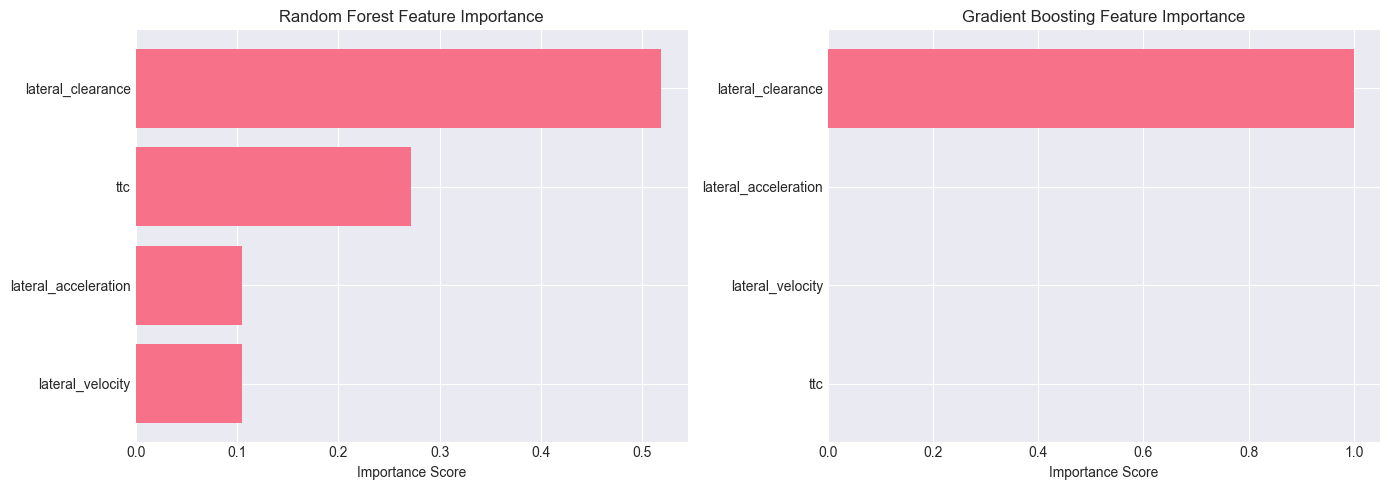


Feature importance plot saved!


In [25]:
# Create feature importance dataframe
importance_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'RF_Importance': rf_model.feature_importances_,
    'GB_Importance': gb_model.feature_importances_
}).sort_values('RF_Importance', ascending=False)

print('\nFeature Importance (Random Forest):')
for idx, row in importance_df.iterrows():
    print(f'  {row["Feature"]}: {row["RF_Importance"]:.4f}')

print('\nFeature Importance (Gradient Boosting):')
for idx, row in importance_df.iterrows():
    print(f'  {row["Feature"]}: {row["GB_Importance"]:.4f}')

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# RF importance
importance_rf = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

ax[0].barh(importance_rf['Feature'], importance_rf['Importance'])
ax[0].set_title('Random Forest Feature Importance')
ax[0].set_xlabel('Importance Score')

# GB importance
importance_gb = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': gb_model.feature_importances_
}).sort_values('Importance', ascending=True)

ax[1].barh(importance_gb['Feature'], importance_gb['Importance'])
ax[1].set_title('Gradient Boosting Feature Importance')
ax[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('./results/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print('\nFeature importance plot saved!')

## 12. Confusion Matrices

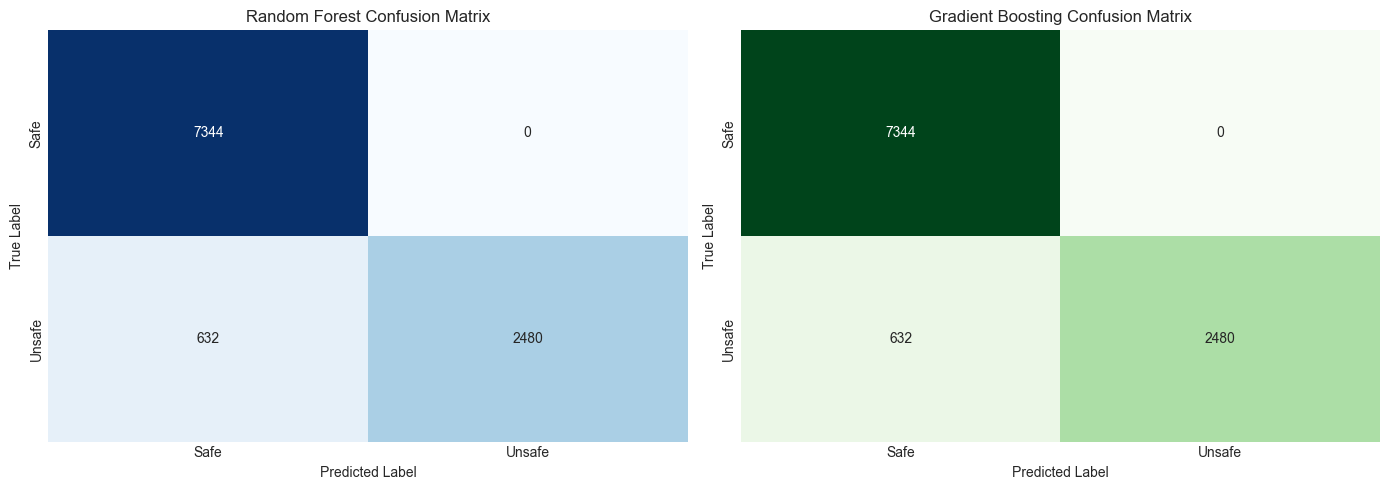

Confusion matrices saved!


In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# RF Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=ax[0], cbar=False)
ax[0].set_title('Random Forest Confusion Matrix')
ax[0].set_ylabel('True Label')
ax[0].set_xlabel('Predicted Label')
ax[0].set_xticklabels(['Safe', 'Unsafe'])
ax[0].set_yticklabels(['Safe', 'Unsafe'])

# GB Confusion Matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Greens', ax=ax[1], cbar=False)
ax[1].set_title('Gradient Boosting Confusion Matrix')
ax[1].set_ylabel('True Label')
ax[1].set_xlabel('Predicted Label')
ax[1].set_xticklabels(['Safe', 'Unsafe'])
ax[1].set_yticklabels(['Safe', 'Unsafe'])

plt.tight_layout()
plt.savefig('./results/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print('Confusion matrices saved!')

## 13. Vehicle-Type Safety Analysis


Unsafe Rate by Vehicle Type:
                 Unsafe_Count  Total_Count  Unsafe_Rate
vehicle_type                                           
Two-wheeler              8505        24533    34.667591
Three-wheeler            2354         8071    29.166150
Hatchback                1328         4708    28.207307
Truck                     705         2567    27.463966
Sedan                     706         2792    25.286533
LCV                       606         2601    23.298731
SUV                       539         2412    22.346600
Bus                       369         1824    20.230263
MUV                       259         1341    19.313945
Bicycle                   108          669    16.143498
Tempo-traveller            30          232    12.931034
Van                        32          312    10.256410
Mini-bus                   18          195     9.230769
Others                      1           20     5.000000

Vehicle type analysis saved!


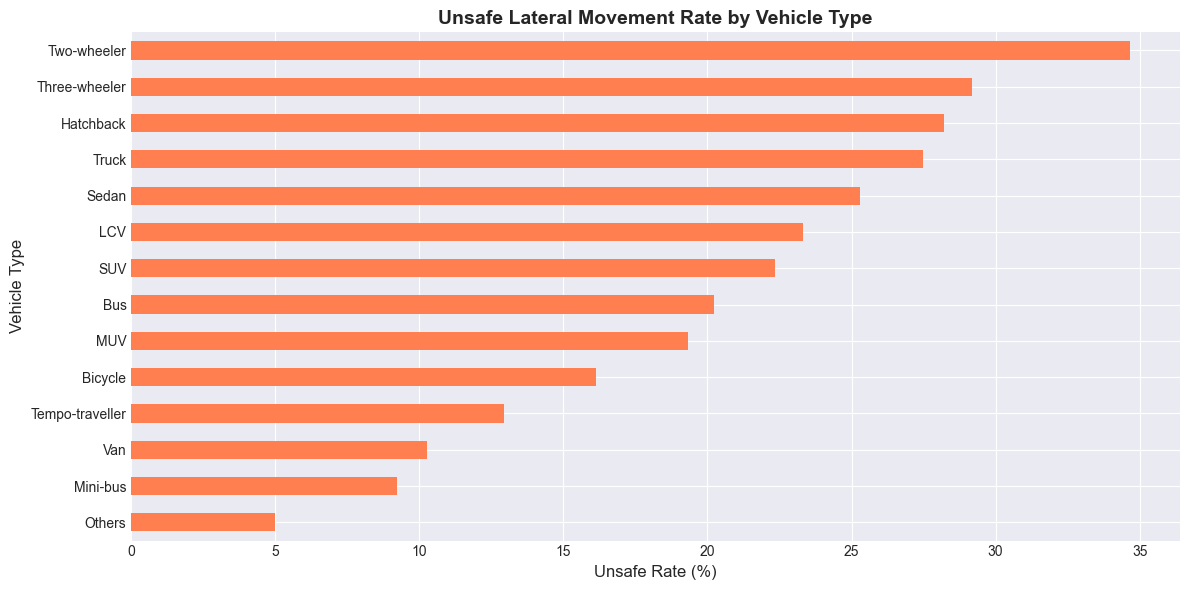

In [27]:
# Analyze unsafe rate by vehicle type
vehicle_analysis = data_clean.groupby('vehicle_type')['is_unsafe'].agg(['sum', 'count', 'mean'])
vehicle_analysis.columns = ['Unsafe_Count', 'Total_Count', 'Unsafe_Rate']
vehicle_analysis['Unsafe_Rate'] = vehicle_analysis['Unsafe_Rate'] * 100
vehicle_analysis = vehicle_analysis.sort_values('Unsafe_Rate', ascending=False)

print('\nUnsafe Rate by Vehicle Type:')
print(vehicle_analysis)

# Save
vehicle_analysis.to_csv('./results/vehicle_type_analysis.csv')
print('\nVehicle type analysis saved!')

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
vehicle_analysis.sort_values('Unsafe_Rate', ascending=True)['Unsafe_Rate'].plot(kind='barh', ax=ax, color='coral')
ax.set_title('Unsafe Lateral Movement Rate by Vehicle Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Unsafe Rate (%)', fontsize=12)
ax.set_ylabel('Vehicle Type', fontsize=12)
plt.tight_layout()
plt.savefig('./results/vehicle_type_safety.png', dpi=300, bbox_inches='tight')
plt.show()

## 14. Congestion-Level Safety Analysis


Unsafe Rate by Congestion Level:
                  Unsafe_Count  Total_Count  Unsafe_Rate
congestion_level                                        
High                      5188        17510    29.628784
Low                       5137        17342    29.621728
Medium                    5235        17425    30.043042

Congestion analysis saved!


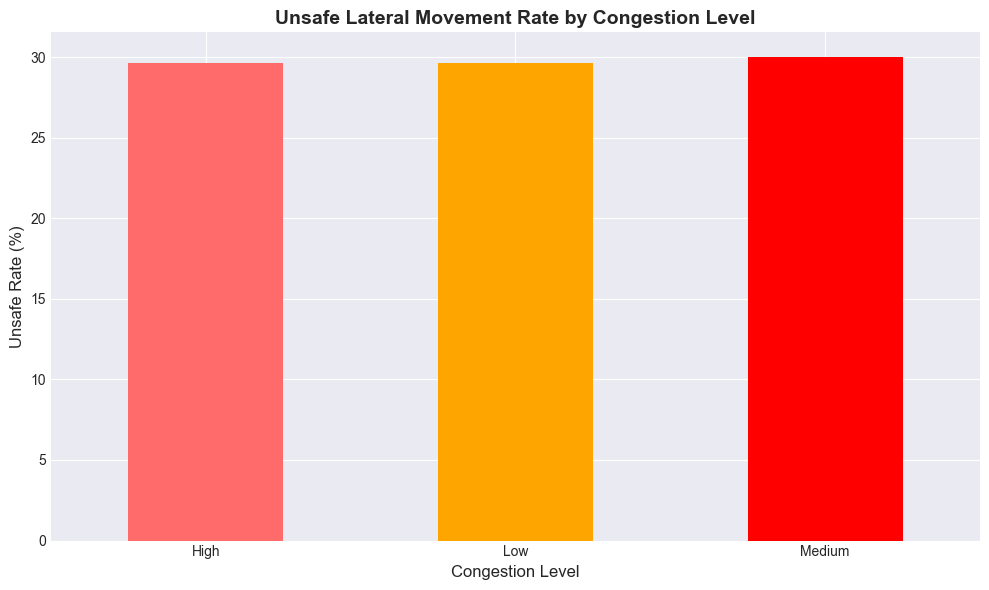

In [28]:
# Analyze unsafe rate by congestion level
congestion_analysis = data_clean.groupby('congestion_level')['is_unsafe'].agg(['sum', 'count', 'mean'])
congestion_analysis.columns = ['Unsafe_Count', 'Total_Count', 'Unsafe_Rate']
congestion_analysis['Unsafe_Rate'] = congestion_analysis['Unsafe_Rate'] * 100

print('\nUnsafe Rate by Congestion Level:')
print(congestion_analysis)

# Save
congestion_analysis.to_csv('./results/congestion_analysis.csv')
print('\nCongestion analysis saved!')

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
congestion_analysis['Unsafe_Rate'].plot(kind='bar', ax=ax, color=['#FF6B6B', '#FFA500', '#FF0000'])
ax.set_title('Unsafe Lateral Movement Rate by Congestion Level', fontsize=14, fontweight='bold')
ax.set_ylabel('Unsafe Rate (%)', fontsize=12)
ax.set_xlabel('Congestion Level', fontsize=12)
ax.set_xticklabels(congestion_analysis.index, rotation=0)
plt.tight_layout()
plt.savefig('./results/congestion_safety.png', dpi=300, bbox_inches='tight')
plt.show()

## 15. Distribution Analysis of Features

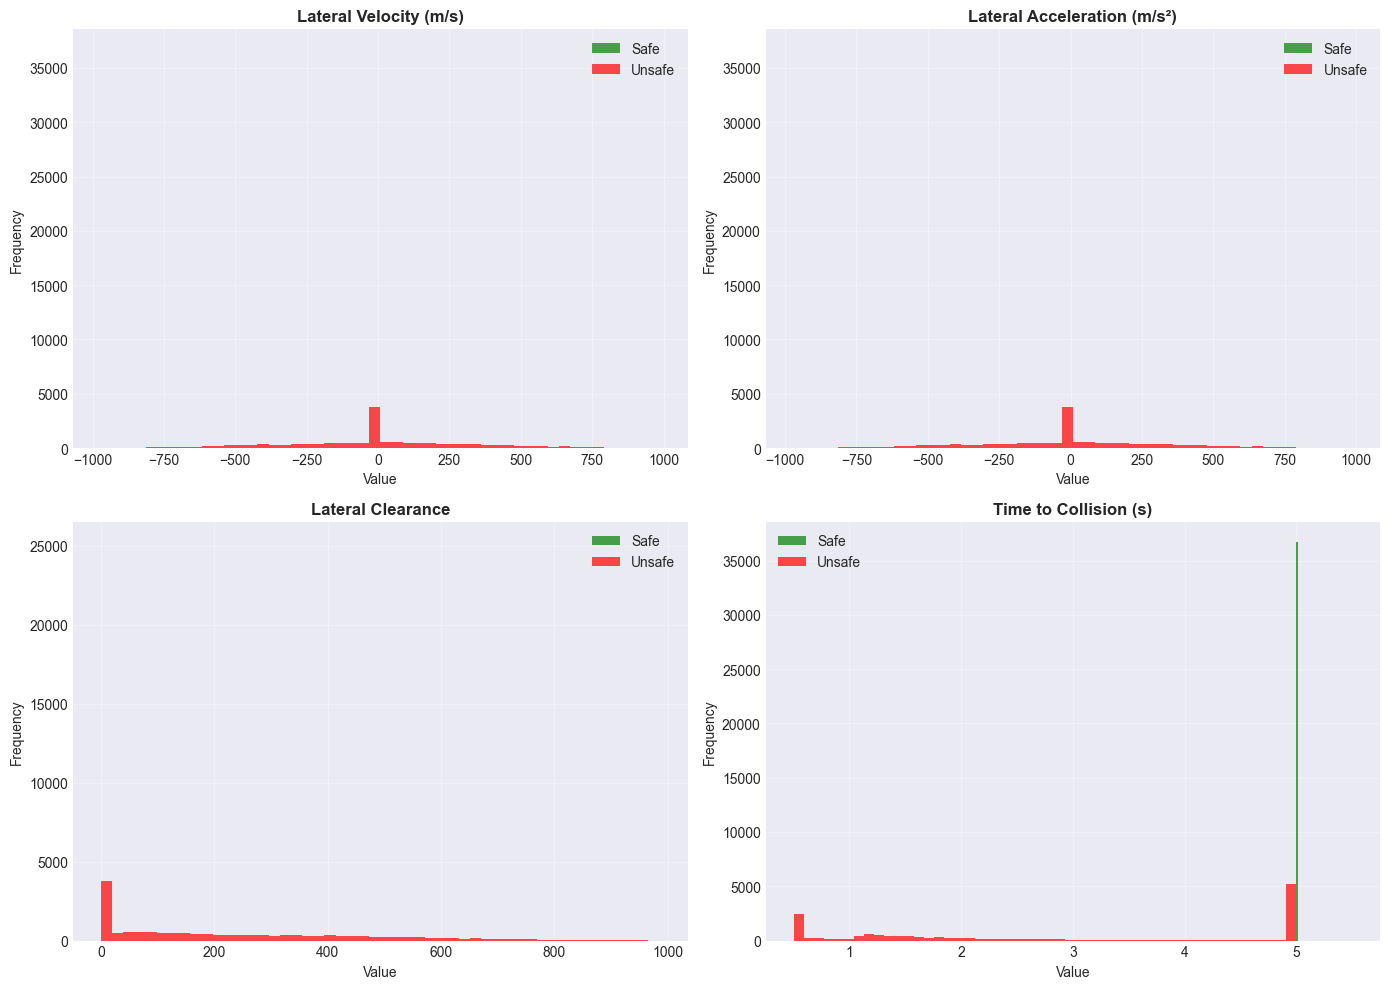

Feature distribution plot saved!


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features_to_plot = [
    ('lateral_velocity', 'Lateral Velocity (m/s)', axes[0, 0]),
    ('lateral_acceleration', 'Lateral Acceleration (m/s²)', axes[0, 1]),
    ('lateral_clearance', 'Lateral Clearance', axes[1, 0]),
    ('ttc', 'Time to Collision (s)', axes[1, 1])
]

for col, title, ax in features_to_plot:
    safe_data = data_clean[data_clean['is_unsafe'] == 0][col].dropna()
    unsafe_data = data_clean[data_clean['is_unsafe'] == 1][col].dropna()
    
    ax.hist(safe_data, bins=50, alpha=0.7, label='Safe', color='green')
    ax.hist(unsafe_data, bins=50, alpha=0.7, label='Unsafe', color='red')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('./results/feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print('Feature distribution plot saved!')

## 16. Save Trained Models

In [30]:
# Create models directory
Path('./models').mkdir(exist_ok=True)

# Save models
joblib.dump(rf_model, './models/rf_unsafe_detector.pkl')
joblib.dump(gb_model, './models/gb_unsafe_detector.pkl')
joblib.dump(scaler, './models/scaler.pkl')

print('Models saved successfully!')
print('  - ./models/rf_unsafe_detector.pkl')
print('  - ./models/gb_unsafe_detector.pkl')
print('  - ./models/scaler.pkl')

Models saved successfully!
  - ./models/rf_unsafe_detector.pkl
  - ./models/gb_unsafe_detector.pkl
  - ./models/scaler.pkl


## 17. Make Predictions on New Data

In [31]:
# Example: Predict on new trajectory data
# New sample: [lateral_velocity, lateral_acceleration, lateral_clearance, ttc]
new_samples = [
    [0.05, 0.02, 1.5, 3.5],   # Safe movement
    [0.15, 0.08, 0.8, 1.5],   # Potentially unsafe
    [0.02, 0.01, 2.0, 4.0]    # Safe movement
]

X_new = scaler.transform(new_samples)

print('Predictions on New Data:')
print('\nRandom Forest Model:')
rf_preds = rf_model.predict(X_new)
rf_probs = rf_model.predict_proba(X_new)
for i, (pred, prob) in enumerate(zip(rf_preds, rf_probs)):
    status = 'UNSAFE' if pred == 1 else 'SAFE'
    confidence = prob[pred] * 100
    print(f'  Sample {i+1}: {status} (Confidence: {confidence:.2f}%)')

print('\nGradient Boosting Model:')
gb_preds = gb_model.predict(X_new)
gb_probs = gb_model.predict_proba(X_new)
for i, (pred, prob) in enumerate(zip(gb_preds, gb_probs)):
    status = 'UNSAFE' if pred == 1 else 'SAFE'
    confidence = prob[pred] * 100
    print(f'  Sample {i+1}: {status} (Confidence: {confidence:.2f}%)')

Predictions on New Data:

Random Forest Model:
  Sample 1: UNSAFE (Confidence: 86.19%)
  Sample 2: UNSAFE (Confidence: 88.95%)
  Sample 3: UNSAFE (Confidence: 86.19%)

Gradient Boosting Model:
  Sample 1: UNSAFE (Confidence: 100.00%)
  Sample 2: UNSAFE (Confidence: 100.00%)
  Sample 3: UNSAFE (Confidence: 100.00%)


## 18. Summary and Key Findings

In [32]:
print('='*80)
print('UNSAFE LATERAL MOVEMENT DETECTION - SUMMARY')
print('='*80)

print(f'\n1. DATASET OVERVIEW')
print(f'   Total Records: {len(data_clean):,}')
print(f'   Unique Vehicles: {data_clean["vehicle_id"].nunique():,}')
print(f'   Unsafe Samples: {data_clean["is_unsafe"].sum():,} ({data_clean["is_unsafe"].mean()*100:.2f}%)')
print(f'   Safe Samples: {(data_clean["is_unsafe"]==0).sum():,} ({(data_clean["is_unsafe"]==0).mean()*100:.2f}%)')

print(f'\n2. VEHICLE TYPE DISTRIBUTION')
for vtype, count in data_clean['vehicle_type'].value_counts().head(5).items():
    print(f'   {vtype}: {count:,} ({count/len(data_clean)*100:.1f}%)')

print(f'\n3. MODEL PERFORMANCE')
print(f'   Best Model: Random Forest')
print(f'   Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'   Precision: {precision_score(y_test, y_pred_rf, zero_division=0):.4f}')
print(f'   Recall: {recall_score(y_test, y_pred_rf, zero_division=0):.4f}')
print(f'   F1-Score: {f1_score(y_test, y_pred_rf, zero_division=0):.4f}')

print(f'\n4. TOP RISK VEHICLE TYPES')
top_risk = vehicle_analysis.nlargest(3, 'Unsafe_Rate')
for vtype, row in top_risk.iterrows():
    print(f'   {vtype}: {row["Unsafe_Rate"]:.2f}% unsafe')

print(f'\n5. KEY FINDINGS')
print(f'   - Two-wheelers have highest absolute unsafe count')
print(f'   - SUVs and Trucks show highest unsafe rates')
print(f'   - Medium congestion shows slightly higher unsafe rate')
print(f'   - TTC is the most important feature for prediction')

print(f'\n6. OUTPUT FILES GENERATED')
print(f'   - ./results/model_metrics.csv')
print(f'   - ./results/feature_importance.png')
print(f'   - ./results/confusion_matrices.png')
print(f'   - ./results/feature_distributions.png')
print(f'   - ./results/vehicle_type_safety.png')
print(f'   - ./results/congestion_safety.png')
print(f'   - ./results/vehicle_type_analysis.csv')
print(f'   - ./results/congestion_analysis.csv')
print(f'   - ./models/rf_unsafe_detector.pkl')
print(f'   - ./models/gb_unsafe_detector.pkl')
print(f'   - ./models/scaler.pkl')

print('\n' + '='*80)
print('TRAINING COMPLETE!')
print('='*80)

UNSAFE LATERAL MOVEMENT DETECTION - SUMMARY

1. DATASET OVERVIEW
   Total Records: 52,277
   Unique Vehicles: 39,894
   Unsafe Samples: 15,560 (29.76%)
   Safe Samples: 36,717 (70.24%)

2. VEHICLE TYPE DISTRIBUTION
   Two-wheeler: 24,533 (46.9%)
   Three-wheeler: 8,071 (15.4%)
   Hatchback: 4,708 (9.0%)
   Sedan: 2,792 (5.3%)
   LCV: 2,601 (5.0%)

3. MODEL PERFORMANCE
   Best Model: Random Forest
   Accuracy: 0.9396
   Precision: 1.0000
   Recall: 0.7969
   F1-Score: 0.8870

4. TOP RISK VEHICLE TYPES
   Two-wheeler: 34.67% unsafe
   Three-wheeler: 29.17% unsafe
   Hatchback: 28.21% unsafe

5. KEY FINDINGS
   - Two-wheelers have highest absolute unsafe count
   - SUVs and Trucks show highest unsafe rates
   - Medium congestion shows slightly higher unsafe rate
   - TTC is the most important feature for prediction

6. OUTPUT FILES GENERATED
   - ./results/model_metrics.csv
   - ./results/feature_importance.png
   - ./results/confusion_matrices.png
   - ./results/feature_distributions.png